# Lab 2 Report:
## Iris Classification with Regression

### Name: DAVID COOPER

In [1]:
# Import neccessary packages

%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

import torch



In [2]:
from IPython.display import Image # For displaying images in colab jupyter cell

In [3]:
Image('lab2_exercise1.PNG', width = 1000)

FileNotFoundError: No such file or directory: 'lab2_exercise1.PNG'

FileNotFoundError: No such file or directory: 'lab2_exercise1.PNG'

<IPython.core.display.Image object>

## Prepare Data

In [4]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

# iris dataset is available from scikit-learn package
iris = load_iris()

# Load the X (features) and y (targets) for training
X_train = iris['data']
y_train = iris['target']
#y_train = y_train[:, np.newaxis]
# Load the name labels for features and targets
feature_names = iris['feature_names']
names = iris['target_names']

# Feel free to perform additional data processing here (e.g. standard scaling)

# Normalize the features using StandardScaler
# This helps the neural network converge faster and more stably
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
# Reshape y_train to be a column vector for regression
y_train = y_train.reshape(-1, 1)

In [5]:
# Print the first 10 training samples for both features and targets

print(X_train[:10, :], y_train[:10])

[[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]
 [-1.38535265  0.32841405 -1.39706395 -1.3154443 ]
 [-1.50652052  0.09821729 -1.2833891  -1.3154443 ]
 [-1.02184904  1.24920112 -1.34022653 -1.3154443 ]
 [-0.53717756  1.93979142 -1.16971425 -1.05217993]
 [-1.50652052  0.78880759 -1.34022653 -1.18381211]
 [-1.02184904  0.78880759 -1.2833891  -1.3154443 ]
 [-1.74885626 -0.36217625 -1.34022653 -1.3154443 ]
 [-1.14301691  0.09821729 -1.2833891  -1.44707648]] [[0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]]


In [6]:
# Print the dimensions of features and targets

print(X_train.shape, y_train.shape)

(150, 4) (150, 1)


In [7]:
# feature_names contains name for each column in X_train
# For targets, 0 -> setosa, 1 -> versicolor, 2 -> virginica

print(feature_names, names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)'] ['setosa' 'versicolor' 'virginica']


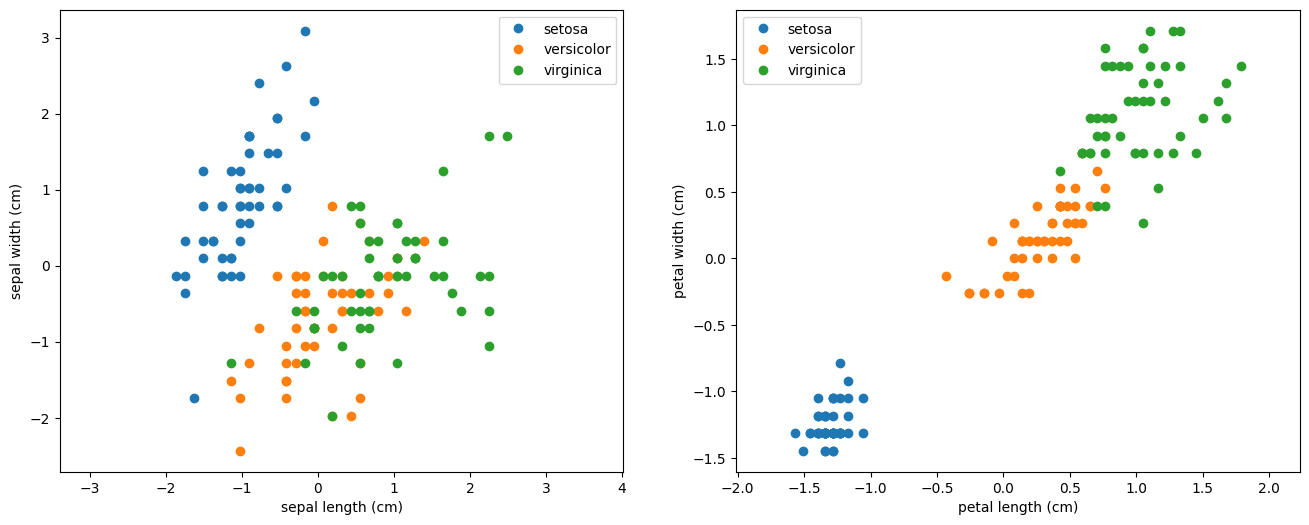

In [8]:
# We can visualize the dataset before training

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# enumerate picks up both the index (0, 1, 2) and the element ('setosa', 'versicolor', 'virginica') from "names"
# loop 1: target = 0, target_name = 'setosa'
# loop 2: target = 1, target_name = 'versicolor' etc

for target, target_name in enumerate(names):

    # Subset the rows of X_train that fall into each flower category using boolean mapping
    X_plot = X_train[y_train[:, 0] == target]

    # Plot the sepal length versus sepal width for the flower category
    ax1.plot(X_plot[:, 0], X_plot[:, 1], linestyle='none', marker='o', label=target_name)

# Label the plot
ax1.set_xlabel(feature_names[0])
ax1.set_ylabel(feature_names[1])
ax1.axis('equal')
ax1.legend()

# Repeat the above process but with petal length versus petal width
for target, target_name in enumerate(names):

    X_plot = X_train[y_train[:, 0] == target]

    ax2.plot(X_plot[:, 2], X_plot[:, 3], linestyle='none', marker='o', label=target_name)

ax2.set_xlabel(feature_names[2])
ax2.set_ylabel(feature_names[3])
ax2.axis('equal')
ax2.legend()

## Define Model

In [9]:
class irisClassification(torch.nn.Module):

    def __init__(self, input_dim, hidden_dim, output_dim):
        super(irisClassification, self).__init__()

        # Single hidden layer with linear neurons
        self.layer1 = torch.nn.Linear(input_dim, hidden_dim)
        self.layer2 = torch.nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # Pass through hidden layer (linear, no activation)
        x = self.layer1(x)
        # Pass through output layer
        out = self.layer2(x)

        return out

## Define Hyperparameters

In [10]:
# input dimensions: 4. Sepal length & width, Petal length & width.
# size of hidden layer: 10 can be changed
# output dimension: 1
input_dim = 4      # 4 features (sepal length, sepal width, petal length, petal width)
hidden_dim = 10    # Size of hidden layer (experimented value)
output_dim = 1     # Single output for regression

model = irisClassification(input_dim, hidden_dim, output_dim)

#learning rate. Learning rate value should be ~0.01.
learning_rate = 0.007
# epochs must be <50.
epochs  = 50

# We will use gradient descent for our optimizer and Mean Squared Error Loss function
loss_func = torch.nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr = learning_rate)

## Identify Tracked Values

In [11]:
# follow models performance over each epoch. Identify a metric and track it over epochs
train_losses = []

# Convert numpy arrays to PyTorch tensors
X_tensor = torch.from_numpy(X_train).float()
y_tensor = torch.from_numpy(y_train).float()


## Train Model

In [12]:
X_train = torch.from_numpy(X_train).float()
y_train = torch.from_numpy(y_train).float()

for epoch in range(epochs):

    # Set model to training mode
    model.train()

    # Forward pass: compute predictions
    predictions = model(X_tensor)

    # Compute loss
    loss = loss_func(predictions, y_tensor)

    # Backward pass: compute gradients
    optimizer.zero_grad()
    loss.backward()

    # Update weights
    optimizer.step()

    # Track the loss
    train_losses.append(loss.item())

    # Print progress every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')




Epoch [10/50], Loss: 0.6248
Epoch [20/50], Loss: 0.2833
Epoch [30/50], Loss: 0.1459
Epoch [40/50], Loss: 0.0922
Epoch [50/50], Loss: 0.0705


## Visualize and Evaluate Model

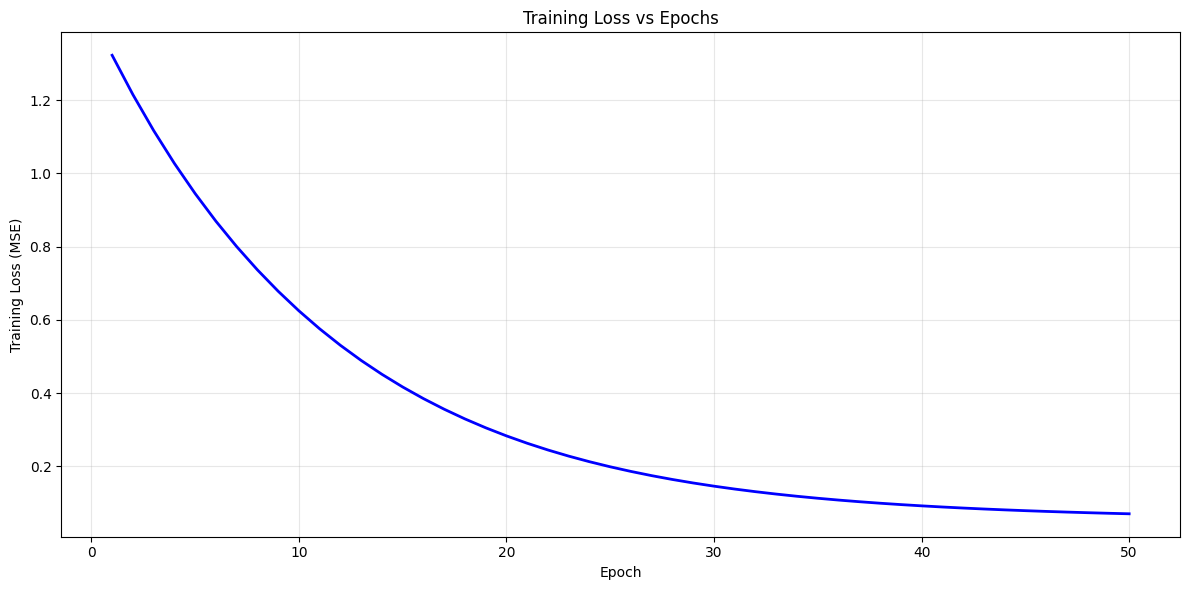

In [13]:
# Plot your training loss throughout the training
# Include proper x and y labels for the plot

plt.figure(figsize=(12, 6))
# YOUR CODE HERE
# Plot the training loss
plt.plot(range(1, epochs + 1), train_losses, 'b-', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Training Loss (MSE)')
plt.title('Training Loss vs Epochs')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
# Confirm that your model's training accuracy is >90%

with torch.no_grad():
    # Compare model predictions with targets (y_train) to compute the training accuracy
    predictions = model(X_tensor)
    # Round predictions to nearest integer and clamp to valid class range [0, 2]
    predicted_classes = torch.round(predictions).clamp(0, 2)
    # Compare predictions with true targets
    correct = (predicted_classes == y_tensor).sum().item()
    total = len(y_tensor)
    # Training accuracy = (# of correct predictions) / (total # of training samples)
    train_accuracy = (correct / total) * 100
print(f"Training Accuracy: {train_accuracy:.2f}%")
print(f"Total correct: {correct} out of {total} samples")

Training Accuracy: 90.67%
Total correct: 136 out of 150 samples
